In [4]:
conda activate webots_env

usage: conda [-h] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'activate' (choose from 'clean', 'compare', 'config', 'create', 'info', 'init', 'install', 'list', 'notices', 'package', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade', 'build', 'convert', 'debug', 'develop', 'doctor', 'index', 'inspect', 'metapackage', 'render', 'skeleton', 'repo', 'token', 'verify', 'env', 'server', 'pack', 'content-trust')

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install bert-score

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install rouge-score

  Using cached rouge_score-0.1.2-py3-none-any.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rouge-score] [nltk]
Note: you may need to restart the kernel to use updated packages.


In [8]:
# VLM Evaluation
import os

def get_folder_names(path, folders=None):
    """
    Recursively finds and returns a list of the deepest folder paths
    that contain at least one JSON file.
    """
    if folders is None:
        folders = []

    for entry in os.listdir(path):
        full_path = os.path.join(path, entry)
        if os.path.isdir(full_path):
            # Check if this subfolder has any JSON files directly inside
            has_json = any(f.endswith(".json") for f in os.listdir(full_path) if os.path.isfile(os.path.join(full_path, f)))
            
            if has_json:
                folders.append(full_path)
            else:
                # Recurse deeper if no JSON files found here
                get_folder_names(full_path, folders)

    return folders


# Example usage:
folders = []
drone_sim_directory = "../results/drone_sim/"  # Replace with your actual folder path
images_sim_directory = "../results/images_sim/"  # Replace with your actual folder path
folders = get_folder_names(drone_sim_directory, folders)
folders = get_folder_names(images_sim_directory, folders)

# folders.remove('.archive')
# folders.remove('detections')

In [9]:
for folder in folders:
    print(folder)

../results/drone_sim/world2_scenario2_rescue/test10
../results/drone_sim/world2_scenario2_rescue/test9
../results/drone_sim/world2_scenario2_rescue/test7
../results/drone_sim/world2_scenario2_rescue/test6
../results/drone_sim/world2_scenario2_rescue/test1
../results/drone_sim/world2_scenario2_rescue/test8
../results/drone_sim/world2_scenario2_rescue/test4
../results/drone_sim/world2_scenario2_rescue/test3
../results/drone_sim/world2_scenario2_rescue/test2
../results/drone_sim/world2_scenario2_rescue/test5
../results/drone_sim/world3_scenario2_rescue/test10
../results/drone_sim/world3_scenario2_rescue/test9
../results/drone_sim/world3_scenario2_rescue/test7
../results/drone_sim/world3_scenario2_rescue/test6
../results/drone_sim/world3_scenario2_rescue/test1
../results/drone_sim/world3_scenario2_rescue/test8
../results/drone_sim/world3_scenario2_rescue/test4
../results/drone_sim/world3_scenario2_rescue/test3
../results/drone_sim/world3_scenario2_rescue/test2
../results/drone_sim/world3_s

In [10]:
import json
import re

In [11]:
def extract_assistance_section(text: str) -> str:
    """
    Return the '3. Assistance needed' section (case-insensitive) including its text.
    If not found, return an empty string.
    """
    text = text.replace("\\n", "\n")

    pattern = r"^\s*3\.\s*Assistance\s+needed\b[:\-–—]?\s*[\s\S]*?(?=(?:\n\s*\d+\.)|$)"
    match = re.search(pattern, text, flags=re.IGNORECASE | re.MULTILINE)
    return match.group(0).strip() if match else None

In [12]:
results_data = []
vlm_responses = {}
llm_responses = {}
assist_inst_resp = {}

for folder in folders:
    path = folder.split('/')
    # print([path[-2][:16]])
    if 'world' == path[-2][:5] and 'scenario' == path[-2][7:15]:
        world_scenario = path[-2][:16]
        file_name = path[-2]+'_'+path[-1]
    else:
        world_scenario = path[-1]
        file_name = path[-1]

    results_file = f'{folder}/results.json'
    vlm_responses.update({world_scenario: []})
    llm_responses.update({world_scenario: []})
    assist_inst_resp.update({world_scenario: []})

    try:
        with open(results_file, 'r') as file:
            raw_data = json.load(file)

            # print(raw_data)

            if isinstance(raw_data, list) and raw_data and isinstance(raw_data[0], str):
                clean_data = [json.loads(item) for item in raw_data]
            else:
                clean_data = raw_data

            # print(clean_data)
        
        for result in clean_data:
            vlm_responses[world_scenario].append(result['vlm_description'])
            llm_responses[world_scenario].append(result['assistance_instructions'])
            
            asst_inst = extract_assistance_section(result['assistance_instructions'])
            # print(asst_inst)
            if asst_inst:
                assist_inst_resp[world_scenario].append(asst_inst)
            

        # print(results_data)
    except FileNotFoundError:
        print(f'{results_file} not found. Confirm file path or results file exsists.')
    except json.JSONDecodeError:
        print(f'{results_file} could not be decoded. Check file format.')
    except Exception as e:
        print(f'Unexcepted error {e}')

# # for resp in vlm_responses:
# #     for vlm_desc in vlm_responses[resp]:
# #         print(vlm_desc)


In [13]:
evaluation_references = 'evaluation_references.json'

try:
    with open(evaluation_references, 'r') as file:
        references = json.load(file)
    # print(results_data)
except FileNotFoundError:
    print(f'{evaluation_references} not found. Confirm file path or results file exsists.')

In [16]:
from bert_score import score

# bert_score dict format:
# {
#   'world_and_scenario' : ''
#   , 'References' : {'VLM': '', LLM: ''}
#   , 'Candidates' : {'VLM': [], LLM: []}
#   , 'Bert_Scores' : {'VLM' : {'P': [], 'R': [], 'F1': []}, 'LLM' : {'P': [], 'R': [], 'F1': []}}
# }
bert_scores = []

# {
#   'world_and_scenario': ''
#   'LLM_Reference' : ''
#   'LLM_Candidate' : ''
#   'LLM_Precision' : ''
#   'LLM_Recall' : ''
#   'LLM_F1 Score' : ''
#   'Person_Found_match': ('True Positive', 'True Negative', 'False Positive', 'False Negative')
#   'Assistance_Required_Match' : ('True Positive', 'True Negative', 'False Positive', 'False Negative')
# }
LLM_bert_scores = []

# {
#   'world_and_scenario': ''
#   'VLM_Reference' : ''
#   'VLM_Candidate' : ''
#   'VLM_Precision' : ''
#   'VLM_Recall' : ''
#   'VLM_F1 Score' : ''
# }
VLM_bert_scores = []

asst_inst_bert_scores = []

vlm_bert = None
llm_bert = None
# asst_inst_bert = None
pattern = r"^\s*3\.\s*Assistance\s+needed\b[:\-–—]?\s*[\s\S]*?(?=(?:\n\s*\d+\.)|$)"

for ref in references:
    vlm_Precision_scores = []
    vlm_Recall_scores = []
    vlm_F1_scores = []

    llm_Precision_scores = []
    llm_Recall_scores = []
    llm_F1_scores = []

    asst_inst_Precision_scores = []
    asst_inst_Recall_scores = []
    asst_inst_F1_scores = []

    world_and_scenario = ref['world_and_scenario']
    vlm_ref = ref['vlm_description']
    llm_ref = ref['llm_response']
    asst_inst_ref = extract_assistance_section(ref['llm_response'])


    vlm_P, vlm_R, vlm_F1 = score(vlm_responses[world_and_scenario], [vlm_ref] * len(vlm_responses[world_and_scenario]), lang='en')
    llm_P, llm_R, llm_F1 = score(llm_responses[world_and_scenario], [llm_ref] * len(llm_responses[world_and_scenario]), lang='en')
    
    # vlm_bleu = sacrebleu.corpus_bleu(vlm_responses[world_and_scenario], vlm_description_ref)
    # llm_bleu = sacrebleu.corpus_bleu(llm_responses[world_and_scenario], llm_description_ref)    

    if assist_inst_resp[world_and_scenario]:
        match = re.search(pattern, ref['llm_response'], flags=re.IGNORECASE | re.MULTILINE)

        if match:
            asst_inst_ref = match.group(0).strip()
        else:
            asst_inst_ref = 'No Instructions.'

        asst_inst_P, asst_inst_R, asst_inst_F1 = score(assist_inst_resp[world_and_scenario], [asst_inst_ref] * len(assist_inst_resp[world_and_scenario]), lang='en')
        # asst_inst_bleu = sacrebleu.corpus_bleu(assist_inst_resp[world_and_scenario], asst_inst_ref)    

        for i, cand in enumerate(assist_inst_resp[world_and_scenario]):
            asst_inst_Precision_scores.append(asst_inst_P[i].item())
            asst_inst_Recall_scores.append(asst_inst_R[i].item())
            asst_inst_F1_scores.append(asst_inst_F1[i].item())

            asst_inst_bert_scores.append({'world_and_scenario' : world_and_scenario
                                        , 'Assistance_Instruction_Reference': asst_inst_ref
                                        , 'Assistance_Instruction_Candidate': cand
                                        , 'Assistance_Instruction_BERT_Precision': asst_inst_P[i].item()
                                        , 'Assistance_Instruction_BERT_Recall': asst_inst_R[i].item()
                                        , 'Assistance_Instruction_BERT_F1_Score': asst_inst_F1[i].item()
                                        # , 'Assistance_Instruction_BLEU_Score': asst_inst_bleu
                                        })


    # print(asst_inst_P, asst_inst_R, asst_inst_F1)


    for i, cand in enumerate(vlm_responses[world_and_scenario]):
        vlm_Precision_scores.append(vlm_P[i].item())
        vlm_Recall_scores.append(vlm_R[i].item())
        vlm_F1_scores.append(vlm_F1[i].item())

        VLM_bert_scores.append({'world_scenario' : world_and_scenario
                                , 'VLM_Reference' : vlm_ref
                                , 'VLM_Candidate' : cand
                                , 'VLM_Precision' : vlm_P[i].item()
                                , 'VLM_Recall': vlm_R[i].item()
                                , 'VLM_F1_Score' : vlm_F1[i].item()
                                # , 'VLM_BLEU_Score': vlm_bleu
                                })
        
    for i, cand in enumerate(llm_responses[world_and_scenario]):
        llm_Precision_scores.append(llm_P[i].item())
        llm_Recall_scores.append(llm_R[i].item())
        llm_F1_scores.append(llm_F1[i].item())

        if '1. Person Found' in llm_ref and '1. Person Found' in cand:
            person_found_match = 'True Positive'
        elif '1. Person Found' in llm_ref and '1. No Person Found' in cand:
            person_found_match = 'False Negative'
        elif '1. No Person Found' in llm_ref and '1. No Person Found' in cand:
            person_found_match = 'True Negative'
        elif '1. No Person Found' in llm_ref and '1. Person Found' in cand:
            person_found_match = 'False Positive'

        assistance_required_match = None

        if '2. Person Requires Immediate Assistance' in llm_ref and '2. Person Requires Immediate Assistance' in cand:
            assistance_required_match = 'True Positive'
        elif '2. Person Requires Immediate Assistance' in llm_ref and '2. Person does not require assistance' in cand:
            assistance_required_match = 'False Negative'
        elif '2. Person does not require assistance' in llm_ref and '2. Person does not require assistance' in cand:
            assistance_required_match = 'True Negative'
        elif '2. Person does not require assistance' in llm_ref and '2. Person Requires Immediate Assistance' in cand:
            assistance_required_match = 'False Positive'

        LLM_bert_scores.append({'world_scenario' : world_and_scenario
                                , 'LLM_Reference' : llm_ref
                                , 'LLM_Candidate' : cand
                                , 'LLM_Precision' : llm_P[i].item()
                                , 'LLM_Recall': llm_R[i].item()
                                , 'LLM_F1_Score' : llm_F1[i].item()
                                , 'Person_Found_Match': person_found_match
                                , 'Assistance_Required_Match': assistance_required_match
                                # , 'LLM_BLEU_Score': llm_bleu
                                })
        
    eval_bert_results = {'world_and_scenario': world_and_scenario
                         , 'References': {'VLM': vlm_ref, 'LLM': llm_ref}
                         , 'Candidates': {'VLM': vlm_responses[world_and_scenario], 'LLM': llm_responses[world_and_scenario]}
                         , 'Bert_Scores': {
                                        'VLM': {'Precision': vlm_Precision_scores, 'Recall': vlm_Recall_scores, 'F1': vlm_F1_scores}
                                        , 'LLM': {'Precision': llm_Precision_scores, 'Recall': llm_Recall_scores, 'F1': llm_F1_scores}
                                        , 'Assistance_Instructions': {'Precision': asst_inst_Precision_scores, 'Recall': asst_inst_Recall_scores, 'F1': asst_inst_F1_scores}
                                }
                        # , 'BLEU_Scores': {'VLM': vlm_bleu, 'LLM': llm_bleu, 'Assistance_Instruction': asst_inst_bleu}
                         }
    
    bert_scores.append(eval_bert_results)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In [18]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [19]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

In [20]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

for ref in references:
    world_and_scenario = ref['world_and_scenario']
    vlm_ref = ref['vlm_description']
    llm_ref = ref['llm_response']
    asst_inst_ref = extract_assistance_section(ref['llm_response'])

    for resp in vlm_responses[world_and_scenario]:
        scores = scorer.score(vlm_ref, resp)

        print(scores['rougeL'].precision, scores['rougeL'].recall, scores['rougeL'].fmeasure)

    

0.04878048780487805 0.3333333333333333 0.0851063829787234
0.09302325581395349 0.6666666666666666 0.16326530612244897
0.09523809523809523 0.6666666666666666 0.16666666666666666
0.07142857142857142 0.5 0.125
0.07142857142857142 0.5 0.125
0.11904761904761904 0.8333333333333334 0.20833333333333331
0.11904761904761904 0.8333333333333334 0.20833333333333331
0.12195121951219512 0.8333333333333334 0.21276595744680848
0.07317073170731707 0.5 0.1276595744680851
0.07317073170731707 0.5 0.1276595744680851
0.05 0.3333333333333333 0.08695652173913045
0.07692307692307693 0.5 0.13333333333333336
0.1282051282051282 0.8333333333333334 0.2222222222222222
0.07692307692307693 0.5 0.13333333333333336
0.07692307692307693 0.5 0.13333333333333336
0.125 0.8333333333333334 0.21739130434782608
0.04878048780487805 0.3333333333333333 0.0851063829787234
0.05 0.3333333333333333 0.08695652173913045
0.07317073170731707 0.5 0.1276595744680851
0.075 0.5 0.13043478260869565
0.07692307692307693 0.5 0.13333333333333336
0.13

In [ ]:
from sentence_transformers import SentenceTransformer, util
from bert_score import score
from rouge_score import rouge_scorer


model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
# Combine BERT, BLEU, and Sem Scores into one file
evaluation_scores_VLM = []
evaluation_scores_LLM = []
evaluation_scores_Assist_Inst = []

pattern = r"^\s*3\.\s*Assistance\s+needed\b[:\-–—]?\s*[\s\S]*?(?=(?:\n\s*\d+\.)|$)"
drone_sim_pattern = r'world\d+_scenario\d+'

for ref in references:
    world_and_scenario = ref['world_and_scenario']
    vlm_ref = ref['vlm_description']
    llm_ref = ref['llm_response']
    asst_inst_ref = extract_assistance_section(ref['llm_response'])
    sim_env = None

    drone_sim_match = re.search(drone_sim_pattern, world_and_scenario, flags=re.IGNORECASE | re.MULTILINE)
    if drone_sim_match:
        sim_env = 'Drone Simulation'
    else:
        sim_env = 'Image Dataset'

    # VLM Evaluation
    print('Evaluating VLM Responses to Reference ', world_and_scenario)
    for resp in vlm_responses[world_and_scenario]:
        evaluation_dict_VLM = { 'Simulation Environment': sim_env
                            , 'World and Scenario': world_and_scenario
                            , 'Reference': vlm_ref
                            , 'Response': resp
                            , 'ROUGE Precision Score': None
                            , 'ROUGE Recall Score': None
                            , 'ROUGE F1 Score': None
                            , 'Sem Score': None
                            , 'BERT Precision Score': None
                            , 'BERT Recall Score': None
                            , 'BERT F1 Score': None}

        # ROUGE Score
        scores = scorer.score(vlm_ref, resp)
        evaluation_dict_VLM['ROUGE Precision Score'] = scores['rougeL'].precision
        evaluation_dict_VLM['ROUGE Recall Score'] = scores['rougeL'].recall
        evaluation_dict_VLM['ROUGE F1 Score'] = scores['rougeL'].fmeasure

        # # SEMScore
        vlm_embeddings = model.encode([vlm_ref, resp], convert_to_tensor=True)
        vlm_sem_score = util.cos_sim(vlm_embeddings[0], vlm_embeddings[1])
        evaluation_dict_VLM['Sem Score'] = vlm_sem_score.item()

        # # BERT Score
        vlm_P, vlm_R, vlm_F1 = score([resp], [vlm_ref], lang='en')
        evaluation_dict_VLM['BERT Precision Score'] = vlm_P.item()
        evaluation_dict_VLM['BERT Recall Score'] = vlm_R.item()
        evaluation_dict_VLM['BERT F1 Score'] = vlm_F1.item()

        # print(evaluation_dict_VLM)
        evaluation_scores_VLM.append(evaluation_dict_VLM)
        # print(evaluation_scores_VLM)

    print('Evaluating LLM Responses to Reference ', world_and_scenario)
    for resp in llm_responses[world_and_scenario]:
        evaluation_dict_LLM = {'Simulation Environment': sim_env
                            ,'World and Scenario': world_and_scenario
                            , 'Reference': llm_ref
                            , 'Response': resp
                            , 'Person Found': None
                            , 'Assistance Required': None
                            , 'ROUGE Precision Score': None
                            , 'ROUGE Recall Score': None
                            , 'ROUGE F1 Score': None
                            , 'Sem Score': None
                            , 'BERT Precision Score': None
                            , 'BERT Recall Score': None
                            , 'BERT F1 Score': None}

        person_found_match = None
        assistance_required_match = None

        # Get classification results
        if '1. Person Found' in llm_ref and '1. Person Found' in resp:
            person_found_match = 'True Positive'
        elif '1. Person Found' in llm_ref and ('1. No Person Found' in resp or '1. Person Found' not in resp):
            person_found_match = 'False Negative'
        elif '1. No Person Found' in llm_ref and ('1. No Person Found' in resp or '1. Person Found' not in resp):
            person_found_match = 'True Negative'
        elif '1. No Person Found' in llm_ref and '1. Person Found' in resp:
            person_found_match = 'False Positive'

        if '2. Person Requires Immediate Assistance' in llm_ref and '2. Person Requires Immediate Assistance' in resp:
            assistance_required_match = 'True Positive'
        elif '2. Person Requires Immediate Assistance' in llm_ref and ('2. Person does not require assistance' in resp or '2. Person Requires Immediate Assistance' not in resp):
            assistance_required_match = 'False Negative'
        elif '2. Person does not require assistance' in llm_ref and ('2. Person does not require assistance' in resp or '2. Person Requires Immediate Assistance' not in resp):
            assistance_required_match = 'True Negative'
        elif '2. Person does not require assistance' in llm_ref and '2. Person Requires Immediate Assistance' in resp:
            assistance_required_match = 'False Positive'

        evaluation_dict_LLM['Person Found'] = person_found_match
        evaluation_dict_LLM['Assistance Required'] = assistance_required_match

        # ROUGE Score
        scores = scorer.score(llm_ref, resp)
        evaluation_dict_LLM['ROUGE Precision Score'] = scores['rougeL'].precision
        evaluation_dict_LLM['ROUGE Recall Score'] = scores['rougeL'].recall
        evaluation_dict_LLM['ROUGE F1 Score'] = scores['rougeL'].fmeasure

        # SEMScore
        llm_embeddings = model.encode([llm_ref, resp], convert_to_tensor=True)
        llm_sem_score = util.cos_sim(llm_embeddings[0], llm_embeddings[1])
        evaluation_dict_LLM['Sem Score'] = llm_sem_score.item()

        # BERT Score
        llm_P, llm_R, llm_F1 = score([resp], [llm_ref], lang='en')
        evaluation_dict_LLM['BERT Precision Score'] = llm_P.item()
        evaluation_dict_LLM['BERT Recall Score'] = llm_R.item()
        evaluation_dict_LLM['BERT F1 Score'] = llm_F1.item()

        evaluation_scores_LLM.append(evaluation_dict_LLM)

    print('Evaluating Assistance Instruction Responses to Reference ', world_and_scenario)
    if assist_inst_resp[world_and_scenario]:
        match = re.search(pattern, ref['llm_response'], flags=re.IGNORECASE | re.MULTILINE)

        if match:
            asst_inst_ref = match.group(0).strip()
        else:
            asst_inst_ref = ''

        for resp in assist_inst_resp[world_and_scenario]:
            evaluation_dict_Assist_Inst = {'Simulation Environment': sim_env
                                        , 'World and Scenario': world_and_scenario
                                        , 'Reference': asst_inst_ref
                                        , 'Response': resp
                                        , 'ROUGE Precision Score': None
                                        , 'ROUGE Recall Score': None
                                        , 'ROUGE F1 Score': None
                                        , 'Sem Score': None
                                        , 'BERT Precision Score': None
                                        , 'BERT Recall Score': None
                                        , 'BERT F1 Score': None}

            # ROUGE Score
            scores = scorer.score(asst_inst_ref, resp)
            evaluation_dict_Assist_Inst['ROUGE Precision Score'] = scores['rougeL'].precision
            evaluation_dict_Assist_Inst['ROUGE Recall Score'] = scores['rougeL'].recall
            evaluation_dict_Assist_Inst['ROUGE F1 Score'] = scores['rougeL'].fmeasure

            # SEMScore
            assist_inst_embeddings = model.encode([asst_inst_ref, resp], convert_to_tensor=True)
            assist_inst_sem_score = util.cos_sim(assist_inst_embeddings[0], assist_inst_embeddings[1])
            evaluation_dict_Assist_Inst['Sem Score'] = assist_inst_sem_score.item()

            # BERT Score
            assist_inst_P, assist_inst_R, assist_inst_F1 = score([resp], [asst_inst_ref], lang='en')
            evaluation_dict_Assist_Inst['BERT Precision Score'] = assist_inst_P.item()
            evaluation_dict_Assist_Inst['BERT Recall Score'] = assist_inst_R.item()
            evaluation_dict_Assist_Inst['BERT F1 Score'] = assist_inst_F1.item()

            evaluation_scores_Assist_Inst.append(evaluation_dict_Assist_Inst)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [23]:
evaluation_scores_VLM_df = pd.DataFrame(evaluation_scores_VLM)
evaluation_scores_LLM_df = pd.DataFrame(evaluation_scores_LLM)
evaluation_scores_Assist_Inst_df = pd.DataFrame(evaluation_scores_Assist_Inst)

In [24]:
bert_score_weight = 0.5
sem_score_weight = 0.3
rouge_score_weight = 0.2

evaluation_scores_VLM_df['Composite Score'] = evaluation_scores_VLM_df['BERT F1 Score'] * bert_score_weight + evaluation_scores_VLM_df['ROUGE F1 Score'] * rouge_score_weight + evaluation_scores_VLM_df['Sem Score'] * sem_score_weight
evaluation_scores_LLM_df['Composite Score'] = evaluation_scores_LLM_df['BERT F1 Score'] * bert_score_weight + evaluation_scores_LLM_df['ROUGE F1 Score'] * rouge_score_weight + evaluation_scores_LLM_df['Sem Score'] * sem_score_weight
evaluation_scores_Assist_Inst_df['Composite Score'] = evaluation_scores_Assist_Inst_df['BERT F1 Score'] * bert_score_weight + evaluation_scores_Assist_Inst_df['ROUGE F1 Score'] * rouge_score_weight + evaluation_scores_Assist_Inst_df['Sem Score'] * sem_score_weight

In [26]:
pip install openpyxl

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [27]:
evaluation_scores_VLM_df.to_excel('Evaluation_Scores_VLM.xlsx', index=False)
evaluation_scores_LLM_df.to_excel('Evaluation_Scores_LLM.xlsx', index=False)
evaluation_scores_Assist_Inst_df.to_excel('Evaluation_Scores_Assist_Inst.xlsx', index=False)

# Create Graphs

In [28]:
drone_sim_VLM_eval_df = evaluation_scores_VLM_df[(evaluation_scores_VLM_df['Simulation Environment'] == 'Drone Simulation')]
image_dataset_VLM_eval_df = evaluation_scores_VLM_df[(evaluation_scores_VLM_df['Simulation Environment'] == 'Image Dataset')]

drone_sim_LLM_eval_df = evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Simulation Environment'] == 'Drone Simulation')]
image_dataset_LLM_eval_df = evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Simulation Environment'] == 'Image Dataset')]

drone_sim_AI_eval_df = evaluation_scores_Assist_Inst_df[(evaluation_scores_Assist_Inst_df['Simulation Environment'] == 'Drone Simulation')]
image_dataset_AI_eval_df = evaluation_scores_Assist_Inst_df[(evaluation_scores_Assist_Inst_df['Simulation Environment'] == 'Image Dataset')]

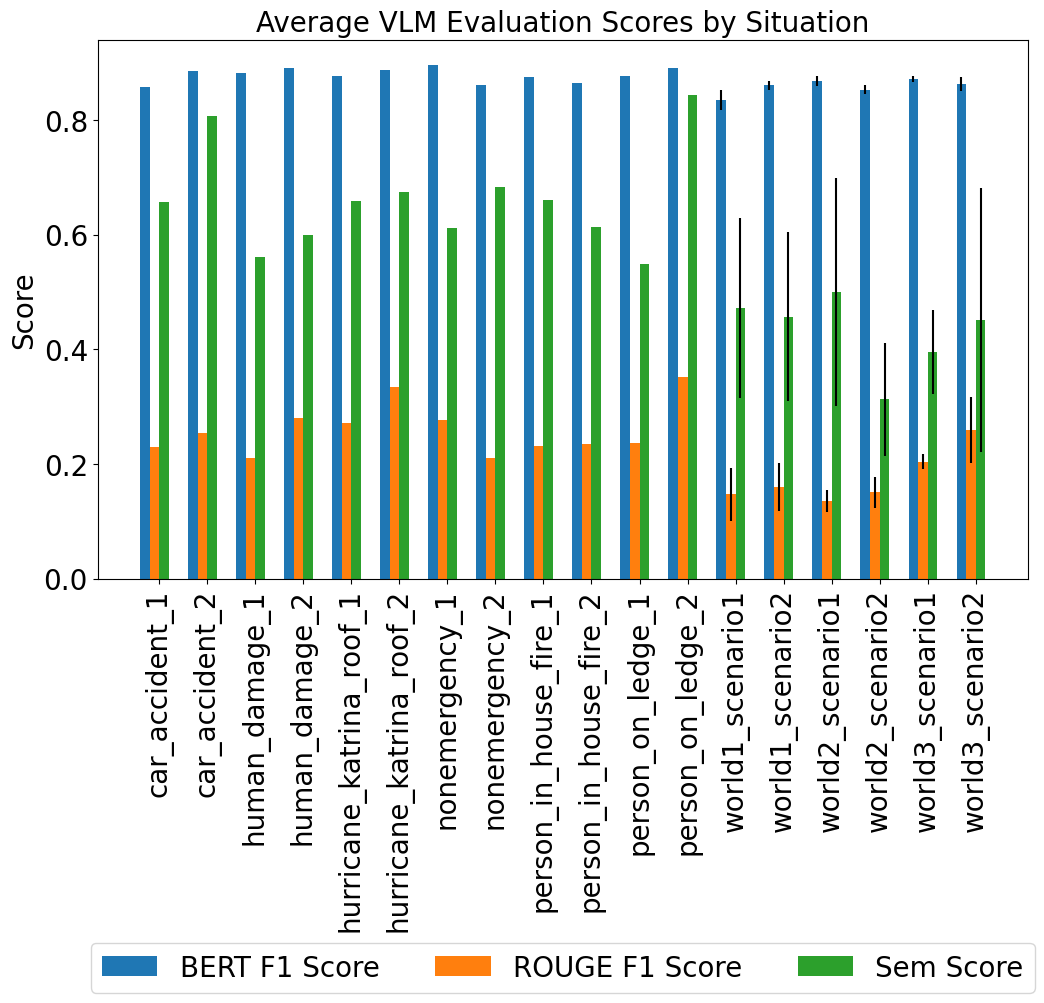

In [95]:
numeric_cols = evaluation_scores_VLM_df.select_dtypes(include='number').columns

grouped = evaluation_scores_VLM_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,7))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Average VLM Evaluation Scores by Situation', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.65), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



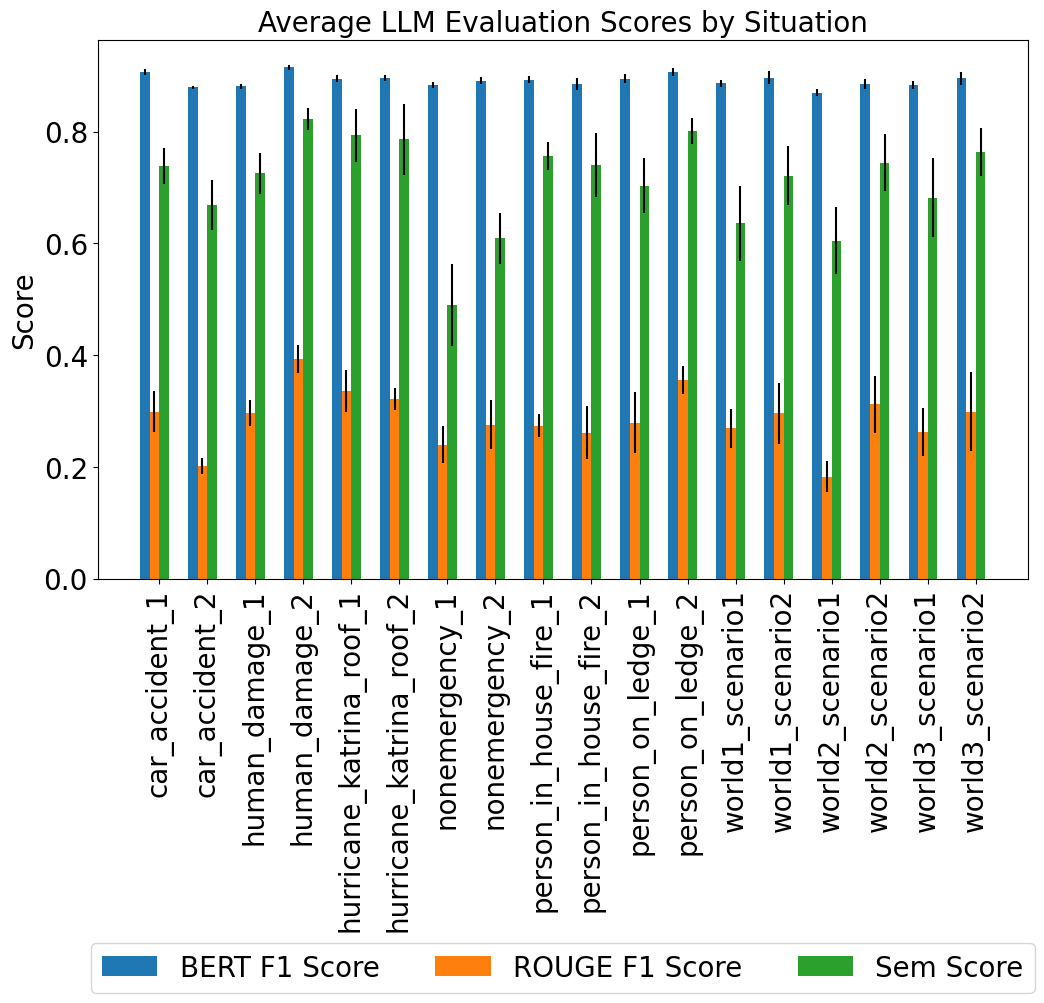

In [96]:
numeric_cols = evaluation_scores_LLM_df.select_dtypes(include='number').columns

grouped = evaluation_scores_LLM_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,7))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Average LLM Evaluation Scores by Situation', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.65), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



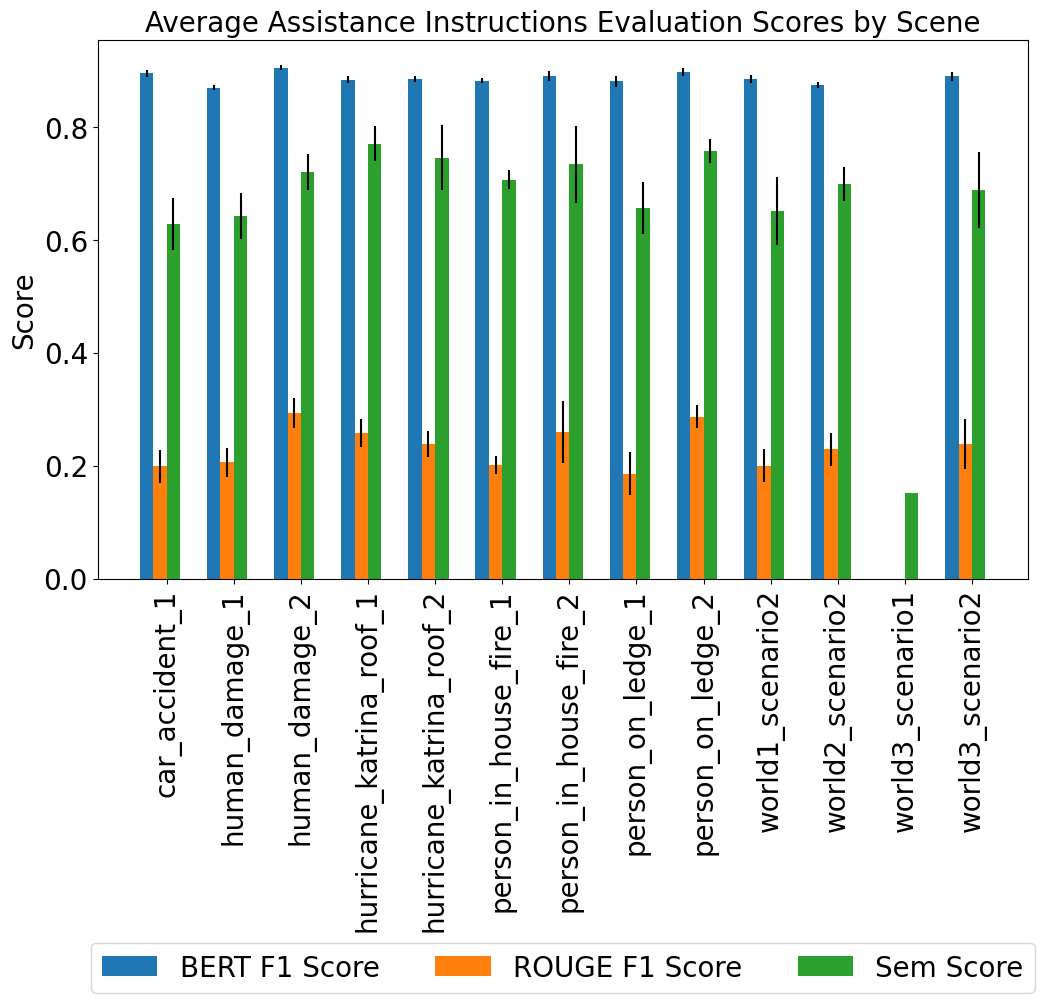

In [97]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = evaluation_scores_Assist_Inst_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,7))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Average Assistance Instructions Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.65), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



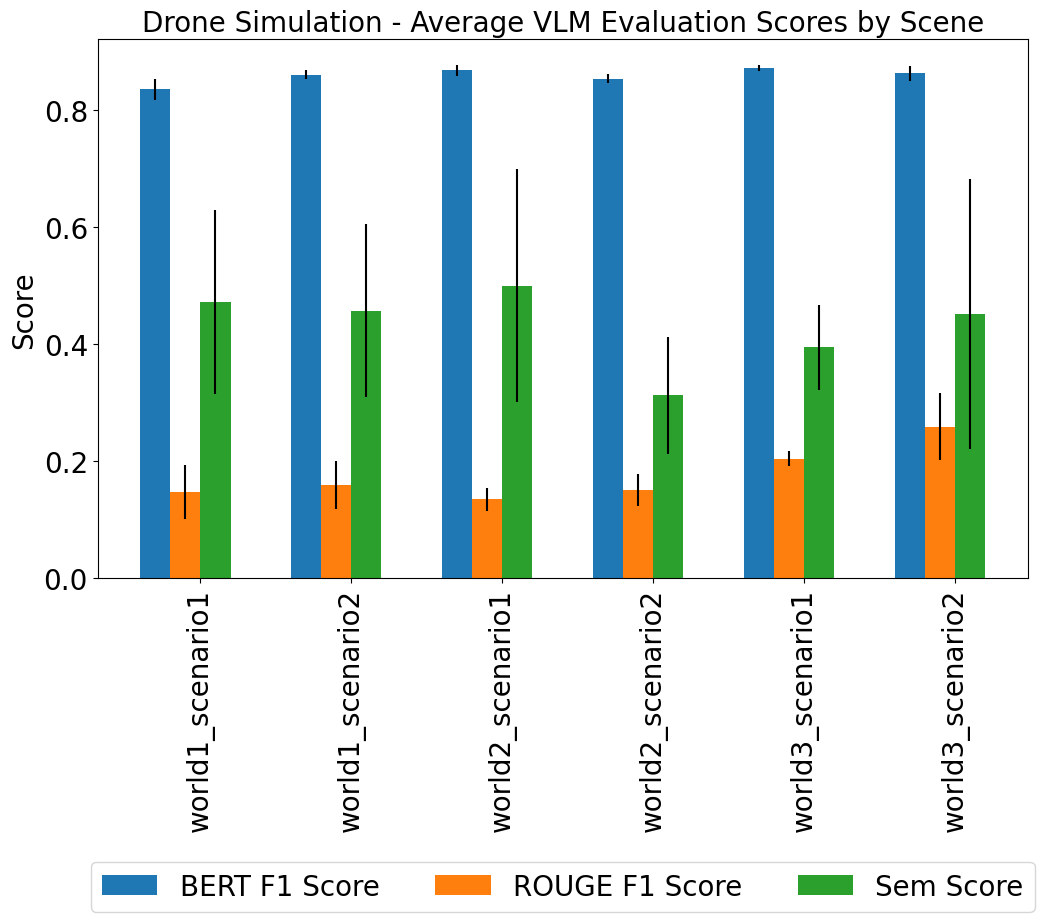

In [98]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = drone_sim_VLM_eval_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,7))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Drone Simulation - Average VLM Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



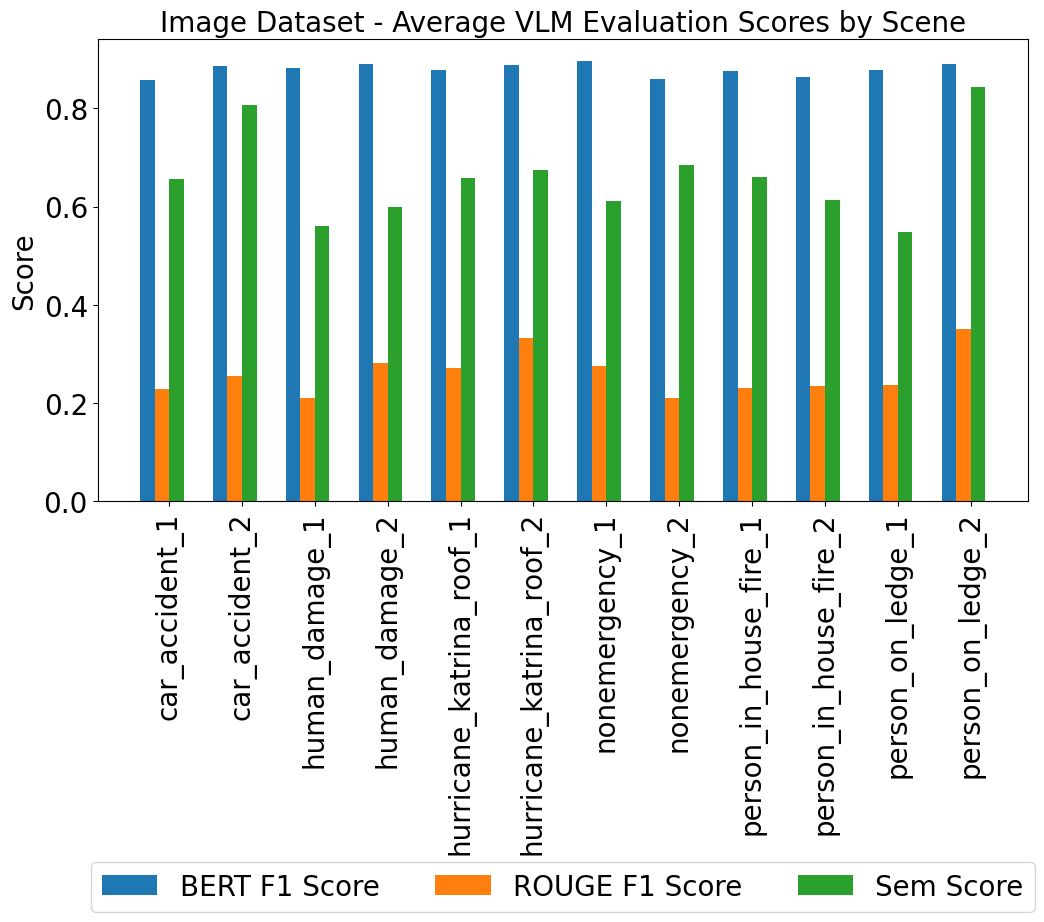

In [99]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = image_dataset_VLM_eval_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Image Dataset - Average VLM Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.75), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



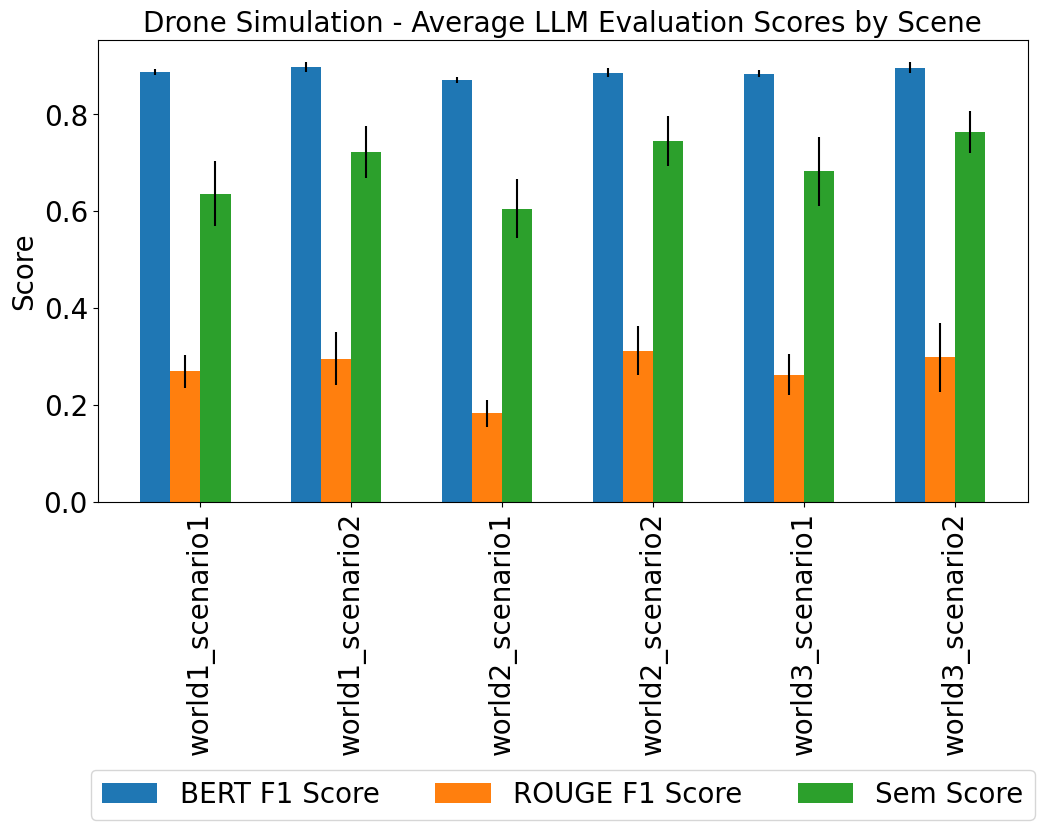

In [100]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = drone_sim_LLM_eval_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = [ 'BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Drone Simulation - Average LLM Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.55), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



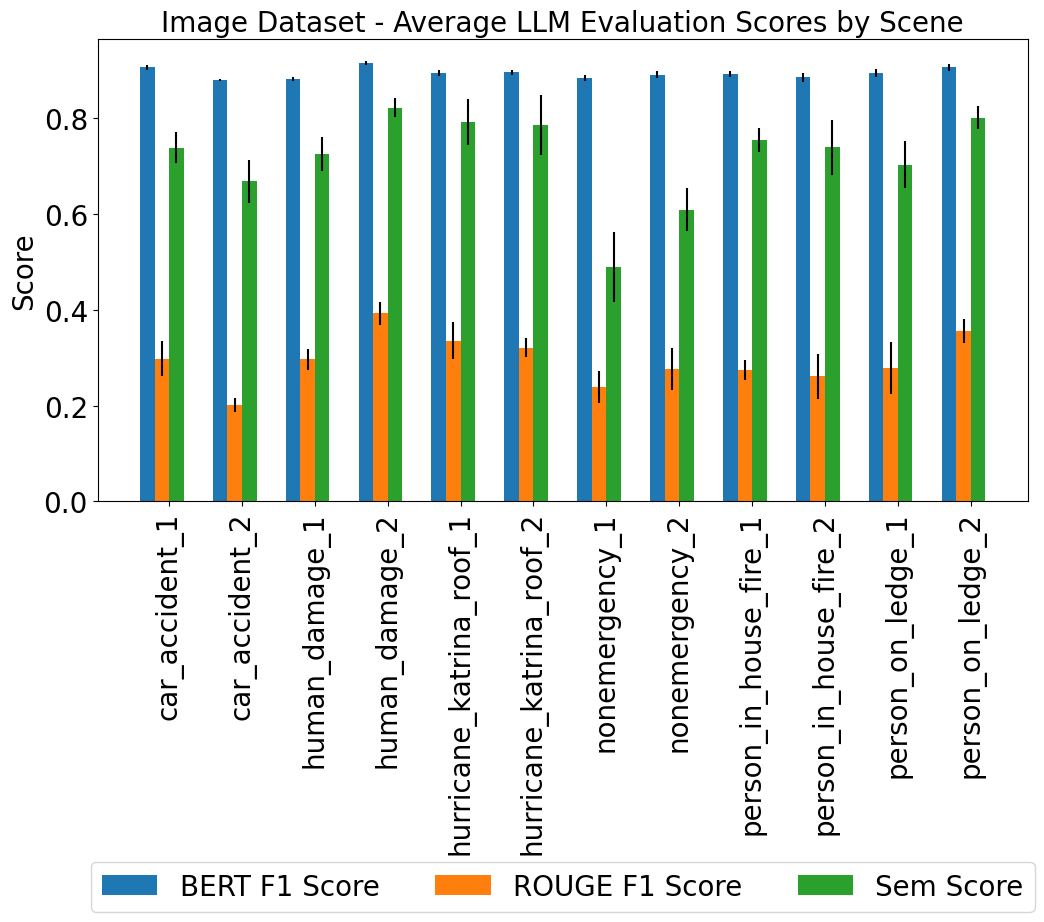

In [101]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = image_dataset_LLM_eval_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Image Dataset - Average LLM Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.75), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()



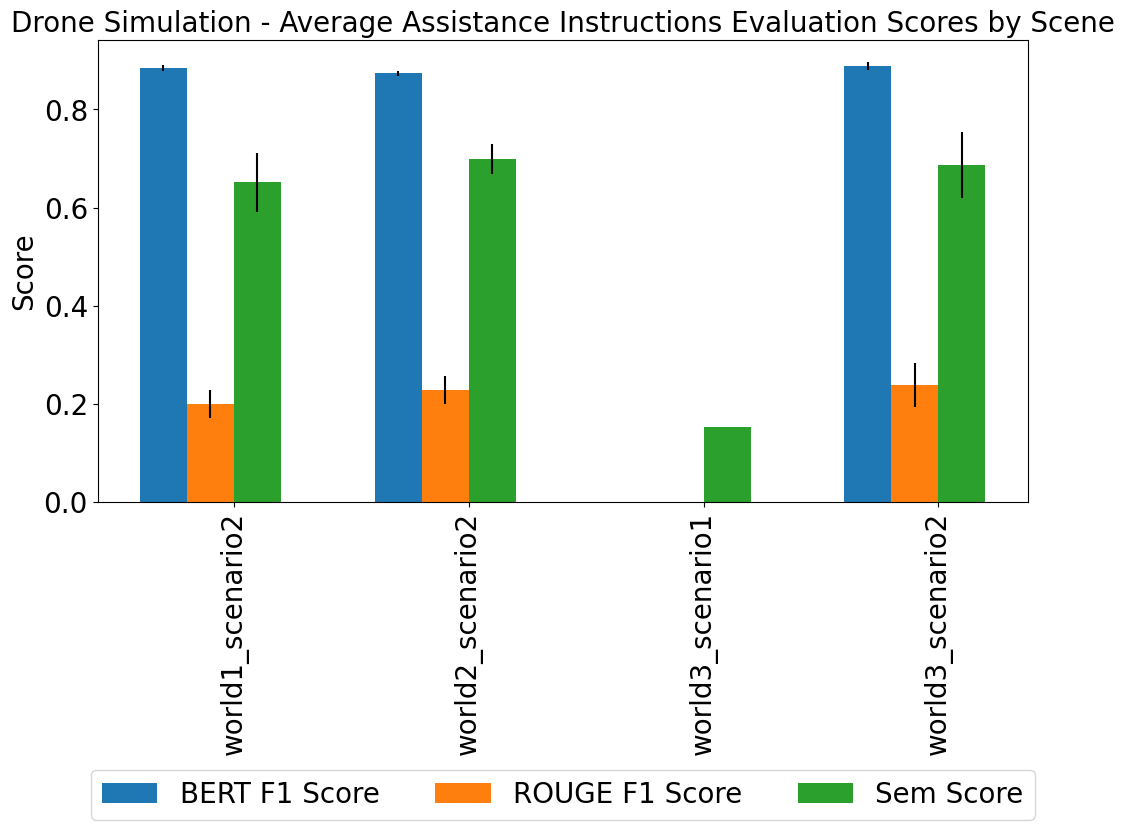

In [102]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = drone_sim_AI_eval_df.groupby('World and Scenario')[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Drone Simulation - Average Assistance Instructions Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.55), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()

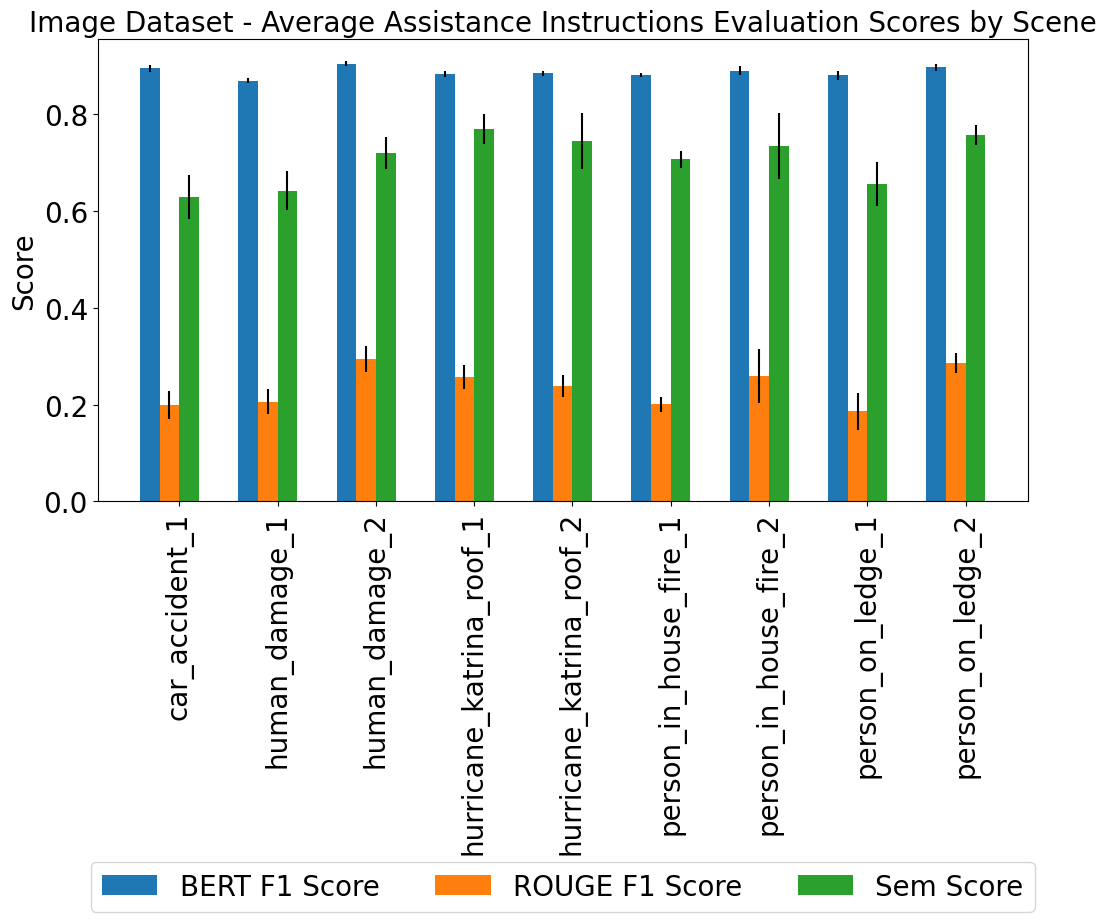

In [103]:
numeric_cols = evaluation_scores_Assist_Inst_df.select_dtypes(include='number').columns

grouped = image_dataset_AI_eval_df.groupby(['World and Scenario'])[numeric_cols].agg(['mean', 'std'])
metrics = ['BERT F1 Score', 'ROUGE F1 Score', 'Sem Score']
x = np.arange(len(grouped))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))


for i, metric in enumerate(metrics):
    means = grouped[(metric, 'mean')]
    stds = grouped[(metric, 'std')]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric)


# Formatting
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)    

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(grouped.index, rotation=90)

ax.set_ylabel('Score', fontsize=20)
ax.set_title('Image Dataset - Average Assistance Instructions Evaluation Scores by Scene', fontsize=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.75), ncol=len(metrics), fontsize=20)
# plt.tight_layout()
plt.show()

In [ ]:
# evaluation_scores_LLM_df['Person Found'].value_counts()
'''
# Get classification results
        if '1. Person Found' in llm_ref and '1. Person Found' in resp:
            person_found_match = 'True Positive'
        elif '1. Person Found' in llm_ref and ('1. No Person Found' in resp or '1. Person Found' not in resp):
            person_found_match = 'False Negative'
        elif '1. No Person Found' in llm_ref and ('1. No Person Found' in resp or '1. Person Found' not in resp):
            person_found_match = 'True Negative'
        elif '1. No Person Found' in llm_ref and '1. Person Found' in resp:
            person_found_match = 'False Positive'

        if '2. Person Requires Immediate Assistance' in llm_ref and '2. Person Requires Immediate Assistance' in resp:
            assistance_required_match = 'True Positive'
        elif '2. Person Requires Immediate Assistance' in llm_ref and ('2. Person does not require assistance' in resp or '2. Person Requires Immediate Assistance' not in resp):
            assistance_required_match = 'False Negative'
        elif '2. Person does not require assistance' in llm_ref and ('2. Person does not require assistance' in resp or '2. Person Requires Immediate Assistance' not in resp):
            assistance_required_match = 'True Negative'
        elif '2. Person does not require assistance' in llm_ref and '2. Person Requires Immediate Assistance' in resp:
            assistance_required_match = 'False Positive'
'''

# Count of True Positives
person_found_tp = len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Person Found'] == 'True Positive')])
person_found_tp_df = evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Person Found'] == 'True Positive')]

assist_req_tp_1 = len(evaluation_scores_LLM_df[ (evaluation_scores_LLM_df['Assistance Required'] == 'True Positive')])
assist_req_tp_2 = len(person_found_tp_df[ (person_found_tp_df['Assistance Required'] == 'True Positive')])

# Count of False Positives
person_found_fp =len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Person Found'] == 'False Positive')])
assist_req_fp_1 = len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Assistance Required'] == 'False Positive')])
assist_req_fp_2 = len(person_found_tp_df[(person_found_tp_df['Assistance Required'] == 'False Positive')])

# Count of True Negatives
person_found_tn =len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Person Found'] == 'True Negative')])
assist_req_tn_1 = len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Assistance Required'] == 'True Negative')])
assist_req_tn_2 = len(person_found_tp_df[(person_found_tp_df['Assistance Required'] == 'True Negative')])

# Count of False Negatives
person_found_fn =len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Person Found'] == 'False Negative')])
assist_req_fn_1 = len(evaluation_scores_LLM_df[(evaluation_scores_LLM_df['Assistance Required'] == 'False Negative')])
assist_req_fn_2 = len(person_found_tp_df[(person_found_tp_df['Assistance Required'] == 'False Negative')])

In [ ]:
evaluation_scores_LLM_df['Person Found'].unique()

array(['False Negative', 'True Positive'], dtype=object)

In [ ]:
print(f'Person Found - TP: {person_found_tp}, FP: {person_found_fp}, TN: {person_found_tn}, FN: {person_found_fn}')
print(f'Assistance Required (Full) - TP: {assist_req_tp_1}, FP: {assist_req_fp_1}, TN: {assist_req_tn_1}, FN: {assist_req_fn_1}')
print(f'Assistance Required (Person Found = TP) - TP: {assist_req_tp_2}, FP: {assist_req_fp_2}, TN: {assist_req_tn_2}, FN: {assist_req_fn_2}')

Person Found - TP: 334, FP: 0, TN: 0, FN: 25
Assistance Required (Full) - TP: 191, FP: 1, TN: 156, FN: 11
Assistance Required (Person Found = TP) - TP: 172, FP: 1, TN: 151, FN: 10


In [ ]:
person_found_P = person_found_tp / (person_found_tp + person_found_fp)
person_found_R = person_found_tp / (person_found_tp + person_found_fn)
person_found_F1 = 2 * (person_found_P * person_found_R) / (person_found_P + person_found_R)

assist_req_1_P = assist_req_tp_1 / (assist_req_tp_1 + assist_req_fp_1)
assist_req_1_R = assist_req_tp_1 / (assist_req_tp_1 + assist_req_fn_1)
assist_req_1_F1 = 2 * (assist_req_1_P * assist_req_1_R) / (assist_req_1_P + assist_req_1_R)

assist_req_2_P = assist_req_tp_2 / (assist_req_tp_2 + assist_req_fp_2)
assist_req_2_R = assist_req_tp_2 / (assist_req_tp_2 + assist_req_fn_2)
assist_req_2_F1 = 2 * (assist_req_2_P * assist_req_2_R) / (assist_req_2_P + assist_req_2_R)

In [ ]:
print(f'Person Found - Precision: {person_found_P:.4f}, Recall: {person_found_R:.4f}, F1 Score: {person_found_F1:.4f}')
print(f'Assistance Required (Full) - Precision: {assist_req_1_P:.4f}, Recall: {assist_req_1_R:.4f}, F1 Score: {assist_req_1_F1:.4f}')
print(f'Assistance Required (Person Found = TP) - Precision: {assist_req_2_P:.4f}, Recall: {assist_req_2_R:.4f}, F1 Score: {assist_req_2_F1:.4f}')

Person Found - Precision: 1.0000, Recall: 0.9304, F1 Score: 0.9639
Assistance Required (Full) - Precision: 0.9948, Recall: 0.9455, F1 Score: 0.9695
Assistance Required (Person Found = TP) - Precision: 0.9942, Recall: 0.9451, F1 Score: 0.9690
